# From Prompts to Harnesses

For a few years the advice for getting more out of a language model was "write a better prompt". It worked, up to a point. Then the interesting progress moved *around* the model: tools it can call, a loop that runs them, a budget for what it sees, checks that run outside it. That surrounding machinery has a name now, the **harness**, and designing it has become a discipline, **harness engineering**.

In this notebook we ask one factual question three ways: with a bare prompt, with a better prompt, and with a small harness. Same model every time. Only the machinery around it changes, and so does the answer.

**What you will learn**

- Why prompt engineering hit a ceiling, and what came after it (a timeline with dates)
- What a harness is, in three definitions and one metaphor
- How to build the smallest possible harness by hand: messages, a model, one tool, a loop
- How the same harness runs on two engines, a real Claude model and a deterministic stand-in
- How the same question comes out three ways, and what each way costs in tokens
- The eight pieces of a harness and where each one lives in the course library

## How to run this notebook

You can run this notebook in two ways:

- **Locally with Jupyter:** open it in Jupyter Notebook, JupyterLab or VS Code and run the cells top to bottom.
- **On Google Colab:** upload the file at [colab.research.google.com](https://colab.research.google.com) (File > Upload notebook) and run the cells top to bottom.

**Which engine drives the harness.** The notebook runs on **real Claude models by default**: `claude-opus-5` for the main agents and `claude-sonnet-5` for helper roles. It finds your key in a file called `.env` at the repository root (copy `.env.example`, fill in `ANTHROPIC_API_KEY=...`; the file is git-ignored). Without a key nothing breaks: the notebook falls back to the **ScriptedModel**, a small Python function that plays the model's part deterministically, and every cell still runs.

A few practical notes:

- **Never paste a key into a cell.** The repository's checks reject notebooks that contain anything that looks like one. On Colab, store the key in the Secrets panel and load it into the environment before the setup cell, or simply run without a key.
- Real runs **cost money and vary between runs** (a few cents for this notebook). Stand-in runs are free and give the same output every time. Section 4 explains the switch and how to force either engine.
- The **setup cell** below downloads the course library (a folder called `harness`, about thirty small files) when it is not already next to the notebook, as on Colab. Locally the folder is already there.
- The hand-built harness in section 3 always runs on the stand-in, on purpose: it is the flight simulator.

In [1]:
# Setup: the notebooks use a small teaching library called `harness` that lives next to them
# in the repository. In Google Colab the folder is not there, so we download it (public files,
# no key, no account). Locally and in CI it is already present.
import pathlib, sys, urllib.request

REPO = "https://raw.githubusercontent.com/maglionejm/fontys-tech-exercises/main/M5%20-%20Harness%20Engineering/"
FILES = [
    "harness/__init__.py",
    "harness/agent.py",
    "harness/context.py",
    "harness/corpus/agent-skills.md",
    "harness/corpus/context-engineering.md",
    "harness/corpus/evals-and-observability.md",
    "harness/corpus/harness-effect.md",
    "harness/corpus/model-context-protocol.md",
    "harness/corpus/multi-agent-systems.md",
    "harness/corpus/prompt-to-harness-timeline.md",
    "harness/corpus/tool-design.md",
    "harness/corpus/what-is-a-harness.md",
    "harness/corpus/workflow-patterns.md",
    "harness/demo_tools.py",
    "harness/evals.py",
    "harness/messages.py",
    "harness/models.py",
    "harness/multi.py",
    "harness/patterns.py",
    "harness/policies.py",
    "harness/providers.py",
    "harness/runtime.py",
    "harness/skills.py",
    "harness/skills/cite-sources/SKILL.md",
    "harness/skills/cite-sources/checklist.md",
    "harness/skills/safe-calculations/SKILL.md",
    "harness/skills/summarize-brief/SKILL.md",
    "harness/skills/summarize-brief/template.md",
    "harness/tools.py",
    "harness/trace.py",
]
if not pathlib.Path("harness/__init__.py").exists():
    for name in FILES:
        target = pathlib.Path(name); target.parent.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve(REPO + name.replace(" ", "%20"), target)
    print(f"Downloaded the harness library ({len(FILES)} files).")
sys.path.insert(0, ".")
import harness
print("harness", harness.__version__, "ready")

# Which engine runs today? A real Claude model when ANTHROPIC_API_KEY is available (loaded from a
# git-ignored .env file at the repository root), otherwise the deterministic ScriptedModel stand-in.
# On Colab the anthropic package is not preinstalled, so install it only when a key is present.
import importlib.util, subprocess
if harness.real_model_available() and importlib.util.find_spec("anthropic") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "anthropic"])

harness 0.2.1 ready


In [2]:
from harness import describe_runtime

print(describe_runtime())

Engine: real Claude models - claude-opus-5 for lead agents, claude-sonnet-5 for workers and judges (key loaded from .env; the key is never printed).


Without a key the notebook runs on the ScriptedModel stand-in and every number is reproducible; with a key it runs on Claude and numbers vary between runs. Never put a key in a cell; use `.env` (see `.env.example` at the repository root).

## 1. Prompt engineering had a ceiling

Two words first, because everything else builds on them.

> A **prompt** is the words you send to the model. **Prompt engineering** is choosing those words well.
>
> A **model** is the text-in, text-out engine. In this module, a model is anything that maps a context (what it is shown) to the next message.

Here is the story in dates. The same text lives in the course library your agent will search later, in a document called `prompt-to-harness-timeline`.

- **2020.** GPT-3 shows that a few examples inside the prompt steer the model (Brown et al., 2020). The words are the lever.
- **January 2022.** Chain-of-thought prompting: ask the model to reason step by step and its answers improve (Wei et al., arXiv 2201.11903). This is the peak of prompt engineering.
- **October 2022.** ReAct interleaves reasoning and actions: think, act, look at the result, think again (Yao et al., arXiv 2210.03629). This is the seed of the agent loop.
- **13 June 2023.** OpenAI ships function calling: the model returns a structured request and your code runs the function. Tool use becomes a product feature.
- **25 November 2024.** Anthropic open-sources the Model Context Protocol, MCP: a standard plug, so any tool server fits any model client. OpenAI adopts it on 26 March 2025.
- **19 December 2024.** Anthropic's "Building effective agents" separates **workflows** (a path you wrote in code, with model steps inside) from **agents** (the model decides the path, step by step, until done), and names five workflow patterns.
- **June 2025.** The industry starts saying **context engineering** instead of prompt engineering: "the delicate art and science of filling the context window with just the right information for the next step" (Andrej Karpathy, 25 June 2025).
- **29 September 2025.** Anthropic publishes "Effective context engineering for AI agents" and the Claude Agent SDK, whose loop is: gather context, take action, verify work, repeat.
- **16 October 2025.** Agent Skills: folders of instructions the agent opens only when a task needs them (Anthropic). Published as an open standard on 18 December 2025.
- **January 2026.** "Demystifying evals for AI agents": an eval is a task, a grader and an outcome, run again and again like a test (Anthropic).
- **11 February 2026.** OpenAI names the discipline **harness engineering** (Ryan Lopopolo, "Harness engineering: leveraging Codex in an agent-first world").
- **July 2026.** The first source-code study of eleven coding agents finds that "the field runs on hand-rolled async loops and deterministic retrieval" (Barbaste, Darrigol, Vu and Wiltberger, arXiv 2609.00006).

**Why the ceiling?** A prompt can only change what the model *says*. It cannot let the model look something up, run a check, or remember what happened an hour ago. Notice that every step after 2022 adds something *around* the model rather than inside the prompt: actions, tools, a standard plug, a loop, a budget, skills, evals.

**Same model, different harness, different score.** The clearest evidence that the surrounding machinery matters comes from benchmarks that hold the model fixed. Claude Opus 4.5 scored 45.9% on SWE-bench Pro under the standardized SEAL scaffold and 55.4% under Claude Code, a 9.5-point gap for the identical model; three harnesses on the same model spanned 50.2% to 55.4%. Third-party monitoring reported up to 11 points of harness-only variation for GPT-5 and 15 points for Kimi K2 Thinking on SWE-bench Verified, and on Terminal-Bench 2 the pass rate rose from 69.7% to 77.0% by changing only the harness ("Stop Comparing LLM Agents Without Disclosing the Harness", arXiv 2605.23950, May 2026; "Harness or Model? Isolating the Harness Effect in Agentic Coding", arXiv 2609.11987, Sep 2026). None of this says the harness beats the model. It says that the harness moves the result by as much as a model upgrade does.

Let us look at the library the agent will search. It holds the module's own reading material, so the agent researches harness engineering while you study it.

In [3]:
from harness.demo_tools import load_corpus

corpus = load_corpus()
print(f"The course library has {len(corpus)} documents:")
for doc in corpus.values():
    print(f"  {doc['id']:<28} {doc['title']}")

The course library has 10 documents:
  agent-skills                 Agent Skills and progressive disclosure
  context-engineering          Context engineering
  evals-and-observability      Evals and observability
  harness-effect               The harness effect: same model, different results
  model-context-protocol       The Model Context Protocol
  multi-agent-systems          Sub-agents, agent teams and handoffs
  prompt-to-harness-timeline   From prompt engineering to harness engineering: a timeline
  tool-design                  Designing tools for agents
  what-is-a-harness            What a harness is
  workflow-patterns            Workflows, agents and guardrails


## 2. What a harness is

Start with something concrete. When you use a coding agent such as Claude Code, Codex CLI or Gemini CLI, the model never touches your files itself. A program around it reads the files, runs the commands, shows the model the results, asks you for permission before anything risky, and decides when the job is done. That program is the harness. Three definitions from 2026 say the same thing with more precision:

1. **Agent = Model + Harness** (Birgitta Bockeler, quoted in Marmelab, "The State of AI Harness Engineering 2026", 24 Sep 2026).
2. "An agent is a model plus a harness: the runtime that couples an LLM to the world through a loop, tools, context management, safety controls, orchestration, and extension surfaces. Harness engineering, named as a discipline in early 2026, is the design and evolution of that runtime." (Barbaste, Darrigol, Vu and Wiltberger, "Harness Engineering: Anatomy, Architecture, and Evolution of Coding Agents", arXiv 2609.00006, Jul 2026)
3. Harness engineering is **deterministic scaffolding around probabilistic model steps**. OpenAI's Ryan Lopopolo described a five-month experiment in which a team shipped about one million lines of production code with zero lines written by hand: the repository was the system of record (design docs, decision records, execution plans, "taste invariants" as versioned markdown) and its rules were enforced mechanically by custom linters and structural tests in CI (OpenAI, "Harness engineering: leveraging Codex in an agent-first world", 11 Feb 2026).

> **In plain words: the model is the engine; the harness is the rest of the car.**

The car metaphor will follow us through the whole module, one part at a time:

| In the car | In the harness |
|---|---|
| the engine | the model |
| steering wheel and pedals | the control loop |
| dashboard and mirrors | context and observability |
| brakes, seatbelts, airbags | guardrails and permissions |
| the route on the GPS | the plan |
| the glovebox manuals | skills, opened only when needed |
| the trailer hitch | tools; MCP is the standard coupling |
| a convoy with a lead car | an orchestrator and its sub-agents |
| a team of drivers sharing one job board | an agent team |

Two more terms you will meet in a minute:

> A **workflow** is a path you wrote in code, with model steps inside. An **agent** is a system where the model decides the path, step by step, until done (Anthropic, "Building effective agents", 19 Dec 2024).
>
> Our **ScriptedModel** is a stand-in for a real model: a small Python function that reads what the model would see and returns the next message. It shows the mechanics without an API key, and because it never changes, any change in the result comes from the harness.

## 3. Build the smallest harness by hand

Before we use the course library, we build a complete harness in about forty lines, so that nothing in it is magic. It has four parts: the messages that travel around, a model, one tool, and the loop that connects them.

This section deliberately stays on a stand-in model whatever engine the rest of the notebook uses. Think of it as the **flight simulator**: every part is visible, nothing is random, and you can break any piece and see exactly what breaks. From section 5 on, the same kind of harness flies with the real engine.

### 3.1 Messages: what travels through the loop

A conversation is a list of messages. Each has a **role** (who wrote it: the user, the assistant, or a tool) and some content. When the model wants to use a tool, its message carries a **tool call**: the name of the tool and its arguments, instead of an answer.

In [4]:
from dataclasses import dataclass, field


@dataclass
class ToolCall:
    name: str            # which tool the model wants
    arguments: dict      # the arguments it wants to pass


@dataclass
class Message:
    role: str            # "user", "assistant" or "tool"
    content: str = ""
    tool_calls: list = field(default_factory=list)


print(Message("user", "When did Anthropic open-source the Model Context Protocol?"))
print(Message("assistant", tool_calls=[ToolCall("search", {"query": "Model Context Protocol"})]))

Message(role='user', content='When did Anthropic open-source the Model Context Protocol?', tool_calls=[])
Message(role='assistant', content='', tool_calls=[ToolCall(name='search', arguments={'query': 'Model Context Protocol'})])


### 3.2 The model: from messages to the next message

A model, for a harness, is just an object with one method: give it the conversation so far and the tools on offer, get the next message back. Our stand-in is a **policy**, a ten-line Python function that decides the next message from what it sees. A real model does the same job with billions of parameters; the interface is identical.

Read the policy as a rule of thumb the model follows: if the last message is a question and a search tool exists, ask for a search; if the last message is a tool result, answer from it; otherwise admit ignorance.

In [5]:
def policy(messages, tools):
    """Our stand-in model: ask for a search first, then answer from what came back."""
    last = messages[-1]
    if last.role == "user" and "search" in tools:
        return Message("assistant", tool_calls=[ToolCall("search", {"query": last.content})])
    if last.role == "tool":
        return Message("assistant", f"According to the library: {last.content}")
    return Message("assistant", "I do not know.")


class ScriptedModel:
    def __init__(self, policy):
        self.policy = policy

    def complete(self, messages, tools):
        return self.policy(messages, tools)


sim_model = ScriptedModel(policy)          # the flight-simulator engine; the library's models come later
print(sim_model.complete([Message("user", "Any question")], tools={}))

Message(role='assistant', content='I do not know.', tool_calls=[])


### 3.3 One tool: a search over three documents

> A **tool** is a function the model can ask for by name, with arguments; the harness runs it and pastes the result back into the conversation.

Our tool searches a library of three one-line documents and returns the one that shares the most words with the query. It is deliberately tiny. The point is that the model cannot read the dictionary itself; it can only ask.

In [6]:
LIBRARY = {
    "mcp": "Anthropic open-sourced the Model Context Protocol on 25 November 2024. "
           "OpenAI adopted it on 26 March 2025.",
    "skills": "Anthropic introduced Agent Skills on 16 October 2025. "
              "A skill is a folder with a SKILL.md file.",
    "harness": "An agent is a model plus a harness. "
               "OpenAI named harness engineering on 11 February 2026.",
}


def search(query: str) -> str:
    """Return the library entry that shares the most words with the query."""
    words = {w.strip("?,.").lower() for w in query.split() if len(w) > 3}
    best = max(LIBRARY, key=lambda key: sum(w in LIBRARY[key].lower() for w in words))
    return f"[{best}] {LIBRARY[best]}"


print(search("When did Anthropic open-source the Model Context Protocol?"))

[mcp] Anthropic open-sourced the Model Context Protocol on 25 November 2024. OpenAI adopted it on 26 March 2025.


### 3.4 The loop: fifteen lines

This is the heart of every harness, from this notebook to Claude Code. Ask the model for the next message. If it is an answer, stop. If it asks for tools, run them, paste the results back, and ask again. A **stop condition** (here, a maximum number of turns) makes sure the loop cannot run forever.

In [7]:
def run_agent(model, tools, task, max_turns=5):
    messages = [Message("user", task)]
    for turn in range(1, max_turns + 1):
        reply = model.complete(messages, tools)          # 1. ask the model for the next message
        messages.append(reply)
        if not reply.tool_calls:                          # 2. no tool requested: this is the answer
            print(f"turn {turn}: answer -> {reply.content}")
            return reply.content
        for call in reply.tool_calls:                     # 3. run each requested tool ...
            result = tools[call.name](**call.arguments)
            print(f"turn {turn}: {call.name}({call.arguments['query']!r}) -> {result[:50]}...")
            messages.append(Message("tool", result))      # ... and paste the result back
    return "Stopped: too many turns."

### 3.5 Run it, without and with the tool

Same model, same question. The first run offers no tools, so the policy has nothing to ask for and gives up. The second run offers the search tool: the model asks for a search, the loop runs it, and the model answers from the result. The model did not get smarter between the two runs. The harness changed.

In [8]:
question = "When did Anthropic open-source the Model Context Protocol?"

print("Without tools:")
run_agent(sim_model, {}, question)

print("\nWith the search tool:")
run_agent(sim_model, {"search": search}, question);

Without tools:
turn 1: answer -> I do not know.

With the search tool:
turn 1: search('When did Anthropic open-source the Model Context Protocol?') -> [mcp] Anthropic open-sourced the Model Context Pro...
turn 2: answer -> According to the library: [mcp] Anthropic open-sourced the Model Context Protocol on 25 November 2024. OpenAI adopted it on 26 March 2025.


That is a harness: messages, a model behind one method, a tool the model can only ask for, and a loop with a stop condition. Everything the course library adds from here on (a system prompt, a token budget, permissions, traces, skills) is a refinement of one of these four parts.

## 4. Two engines, one harness

The course library never hard-codes a model. Every notebook asks for one by **role**:

```python
model, system = model_for("research")
```

`model_for` returns two things: an engine and the system prompt that role needs. Which engine depends on your environment:

- With `ANTHROPIC_API_KEY` available (loaded from the git-ignored `.env` file at the repository root), it returns a real **Claude** model through the official SDK: `claude-opus-5` for main roles (`bare`, `prompted`, `research`, `lead`) and the cheaper `claude-sonnet-5` for helper roles (`worker`, `judge`, `router`, `planner`, `synthesizer`, `calculator`).
- Without a key it returns the **ScriptedModel** stand-in with a policy that imitates that role: a confident guesser for `bare`, a hedger for `prompted`, a tool-using researcher for `research`.
- `model_for(role, real=False)` forces the stand-in even when a key is present. Every notebook uses this for **reference runs**, so the numbers quoted in the course stay reproducible whatever engine you have.

One more difference to keep in mind when you read traces. On the stand-in, token counts are **estimates** (about four characters per token). On Claude, the trace records the **real input tokens** reported by the API for every call. Same harness, same trace format, two engines.

In [9]:
from harness import model_for, describe_runtime

print(describe_runtime())
for role in ("bare", "prompted", "research"):
    model, system = model_for(role)
    print(f"\n{role:<9} -> {type(model).__name__} named {model.name!r}")
    print(f"          system prompt: {system[:105]}...")

stand_in, _ = model_for("research", real=False)
print(f"\nforced stand-in -> {type(stand_in).__name__} named {stand_in.name!r}")

Engine: real Claude models - claude-opus-5 for lead agents, claude-sonnet-5 for workers and judges (key loaded from .env; the key is never printed).



bare      -> AnthropicModel named 'claude-opus-5'
          system prompt: Answer the question directly from what you already know, in one or two sentences. You have no tools....

prompted  -> AnthropicModel named 'claude-opus-5'
          system prompt: You are a careful assistant. Answer in one or two sentences. If you are not sure, say so plainly instead ...

research  -> AnthropicModel named 'claude-opus-5'
          system prompt: You answer questions using ONLY the course library, through your tools. Steps: call search_docs with two ...

forced stand-in -> ScriptedModel named 'scripted-research'


## 5. Same question, three ways, with the library

The course library does what section 3 did, with the parts named and a few refinements: the model sees a **system prompt** (standing instructions placed before the conversation), tools describe themselves to the model, every step is written to a **trace** (the record of every step: messages, tool calls, tokens), and the loop counts tokens.

> A **token** is the unit models read and bill by, roughly four characters of English text. On the stand-in the library estimates tokens with that rule; on Claude it records the real counts.

The three roles from section 4 give us the three approaches:

- `bare`: the model gets the question and nothing else. No tools.
- `prompted`: the same model with the best system prompt we can write for a model that cannot look anything up: be careful, admit uncertainty, name the source that would settle it.
- `research`: the same model with three tools and a loop that runs them. `search_docs` finds documents in the library you listed in section 1, `read_doc` returns one document in full, and `check_citation` checks a draft answer against the document it cites.

The question is chosen so that no model can know the answer from training: it is a figure from a survey published a few days ago, and it is in the course library.

In [10]:
from harness import Agent
from harness.demo_tools import search_docs, read_doc, check_citation

QUESTION = "What share of written security rules did Marmelab's 2026 survey find backed by a real control?"

**Way 1: a bare prompt.**

In [11]:
model, system = model_for("bare")
bare = Agent(model, system=system, name="bare")
r_bare = bare.run(QUESTION)
print(r_bare.answer)

I don't have any knowledge of such a survey. Marmelab is a French web/JavaScript agency (best known for react-admin), and I'm not aware of it publishing a 2026 security-rules survey — that date is also beyond what I reliably know about, so I can't give you a percentage without inventing one. You'd need to check Marmelab's blog or the original report directly.


A model answering from memory cannot produce the figure. The stand-in offers a generic guess; Claude, in the run recorded here, says it has no knowledge of the survey and refuses to invent a percentage. Honest or not, you get no number and nothing you could check.

**Way 2: prompt engineering.** Same question, plus the best system prompt we can write for a model that cannot look anything up.

In [12]:
model, system = model_for("prompted")
prompted = Agent(model, system=system, name="prompted")
r_prompted = prompted.run(QUESTION)
print(r_prompted.answer)

I'm not aware of any such Marmelab survey or that statistic, and I can't verify it — Marmelab is best known as a French web development agency (react-admin), not for security-governance surveys, so I'd be guessing if I named a percentage. To settle it, check Marmelab's own blog/publications (marmelab.com/blog) or ask for the report link; if none exists, the premise may be mistaken.


Better manners, same knowledge. The prompt changed how the model *talks* about what it knows; on Claude the two replies are nearly the same, both declining and pointing to where a source would be. It could not change what the model knows, and it still cannot give you the number. This is the ceiling from section 1.

**Way 3: a harness.** Same model, plus three tools and a loop that runs them.

In [13]:
model, system = model_for("research")
harnessed = Agent(model, tools=[search_docs, read_doc, check_citation], system=system, name="harnessed")
r_harness = harnessed.run(QUESTION)
print(r_harness.answer)

Only 4.4 percent of written security rules are backed by a real control. [source: evals-and-observability]


The figure, in the document's own words, with a `[source: id]` tag pointing at a document anyone can open. The model did not get smarter between the three runs. It was given a way to look things up and a check before it answered.

**The trace is the receipt.** `result.trace.show()` prints every step: each model call with what the model said or asked for, each tool call with its arguments and the start of its result, and the token count per model call. Read the third trace top to bottom: one or more searches, a read, a check, the answer. A real model may ask for several tools in one turn (in the recorded run Claude issued two searches at once); the loop runs them all before calling the model again, which is why the tool-call count can exceed the number of turns.

In [14]:
for result in (r_bare, r_prompted, r_harness):
    result.trace.show()
    print()

trace of 'bare': 1 model calls, 0 tool calls, ~62 tokens
   1  model    claude-opus-5      I don't have any knowledge of such a survey. Marmelab is ...
   1  final    bare               I don't have any knowledge of such a survey. Marmelab is ...

trace of 'prompted': 1 model calls, 0 tool calls, ~83 tokens
   1  model    claude-opus-5      I'm not aware of any such Marmelab survey or that statist...
   1  final    prompted           I'm not aware of any such Marmelab survey or that statist...

trace of 'harnessed': 4 model calls, 4 tool calls, ~8939 tokens
   1  model    claude-opus-5      I'll search the library for this. search_docs({'query': '...
   1  tool     search_docs        (query='Marmelab 2026 survey security rules cont', k='5')...
   1  tool     search_docs        (query='written security policy enforcement shar', k='5')...
   2  model    claude-opus-5      read_doc({'doc_id': 'evals-and-observability'})
   2  tool     read_doc           (doc_id='evals-and-observability') 

Now the same information as a table, so the three approaches can be compared at a glance.

In [15]:
import pandas as pd


def summarize(runs):
    rows = []
    for label, r in runs:
        rows.append({"approach": label,
                     "model calls": r.turns,
                     "tool calls": len(r.trace.tool_calls()),
                     "tokens": r.tokens,
                     "gives the figure": "4.4" in r.answer,
                     "cites a source": "[source:" in r.answer})
    return pd.DataFrame(rows).set_index("approach")


summary = summarize([("bare prompt", r_bare), ("better prompt", r_prompted), ("harness", r_harness)])
summary

,model calls,tool calls,tokens,gives the figure,cites a source
approach,,,,,
bare prompt,1,0,62,False,False
better prompt,1,0,83,False,False
harness,4,4,8939,True,True


The last two columns are the ones that matter in practice: only one of the three answers carries the figure *and* can be checked. The cost of that is visible in the tokens column. A horizontal bar chart makes the gap obvious.

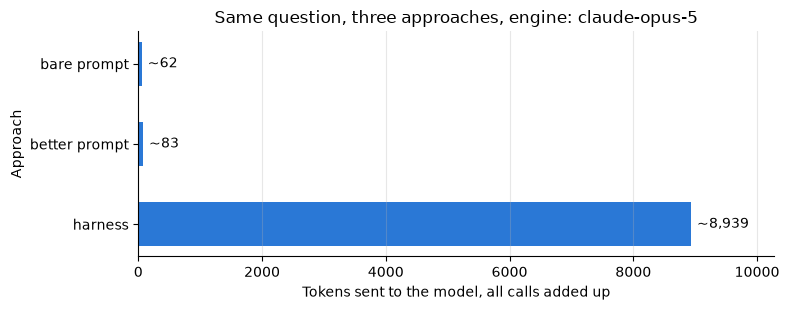

The harness sent about 144 times the tokens of the bare prompt.


In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3.2))
bars = ax.barh(summary.index, summary["tokens"], color="#2a78d6", height=0.55)
ax.bar_label(bars, labels=[f"~{t:,}" for t in summary["tokens"]], padding=4)
ax.set_xlim(0, summary["tokens"].max() * 1.15)
ax.invert_yaxis()                                   # first approach at the top
ax.set_xlabel("Tokens sent to the model, all calls added up")
ax.set_ylabel("Approach")
ax.set_title(f"Same question, three approaches, engine: {harnessed.model.name}")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

ratio = r_harness.tokens / max(r_bare.tokens, 1)
print(f"The harness sent about {ratio:.0f} times the tokens of the bare prompt.")

**How to read it:** each bar is the total number of tokens one approach sent to the model across all its calls; longer is more expensive. The two prompt-only approaches are almost free because they make one call with almost no context. The harness makes several calls, and each one carries the tool results gathered so far, which is where the tokens go.

Tokens are the currency of harness engineering. Everything in the next notebooks (context budgets, compaction, sub-agents, evals) is about spending them where they buy correctness, and nowhere else.

### 5.1 Reference run on the stand-in

Real runs vary: a different phrasing, sometimes a different route through the tools, a different token count. So every notebook also keeps a **reference run** on the deterministic stand-in, with `model_for(role, real=False)`, whose numbers are the ones quoted in the course decks. The stand-in follows its built-in policy and reads the system prompt only for the "say so" cue, so the reference runs keep the short prompts the course numbers were recorded with.

The reference question is a two-part one about the Model Context Protocol. It shows the same pattern with a twist: the stand-in's memory holds a *wrong* answer, and the harness gets the right one out of it anyway.

In [17]:
REFERENCE_QUESTION = ("When did Anthropic open-source the Model Context Protocol, "
                      "and which company adopted it in March 2025?")

ref_bare = Agent(model_for("bare", real=False)[0], name="bare")
ref_prompted = Agent(model_for("prompted", real=False)[0],
                     system="You are a careful assistant. If you are not sure, say so.", name="prompted")
ref_harness = Agent(model_for("research", real=False)[0], tools=[search_docs, read_doc, check_citation],
                    system="Answer from the library and cite.", name="harnessed")

ref_runs = [("bare prompt", ref_bare.run(REFERENCE_QUESTION)),
            ("better prompt", ref_prompted.run(REFERENCE_QUESTION)),
            ("harness", ref_harness.run(REFERENCE_QUESTION))]
for label, r in ref_runs:
    print(f"{label}:\n  {r.answer}\n")
ref_runs[2][1].trace.show()

bare prompt:
  Anthropic released the Model Context Protocol in 2023 and Google adopted it in 2024.

better prompt:
  I am not certain. From memory: Anthropic released the Model Context Protocol in 2023 and Google adopted it in 2024. Please verify this against a source.

harness:
  Anthropic open-sourced the Model Context Protocol on 25 November 2024, with launch partners including Block and Apollo and development tool makers Zed, Replit, Codeium and Sourcegraph. On 26 March 2025 OpenAI announced support for MCP in its Agents SDK, with the ChatGPT desktop application and the Responses API to follow. [source: model-context-protocol]

trace of 'harnessed': 4 model calls, 3 tool calls, ~1980 tokens
   1  model    scripted-research  search_docs({'query': 'anthropic open-source model contex...
   1  tool     search_docs        (query='anthropic open-source model context prot', k='3')...
   2  model    scripted-research  read_doc({'doc_id': 'model-context-protocol'})
   2  tool     read_doc 

In [18]:
reference = summarize(ref_runs).rename(columns={"gives the figure": "correct date"})
reference["correct date"] = [("25 November 2024" in r.answer) for _, r in ref_runs]
reference

,model calls,tool calls,tokens,correct date,cites a source
approach,,,,,
bare prompt,1,0,26,False,False
better prompt,1,0,39,False,False
harness,4,3,1980,True,True


Wrong year and wrong company with full confidence; then the same wrong facts wrapped in a polite hedge; then the right date, the right company and a checked source. These are the numbers the deck for this session quotes, and they are the same every time you run the cell.

## 6. The eight pieces of a harness

The source-code study of eleven coding agents (Barbaste et al., Jul 2026) and Anthropic's engineering posts converge on the same anatomy. We will use these eight pieces, in this order, for the rest of the module. Each one is a class or a function in the course library, so you can open the file and read it; none is longer than two hundred lines.

| # | Piece | In plain words | In the car | In the library |
|---|---|---|---|---|
| 1 | **Model** | the engine; interchangeable behind one interface (context in, next message out) | engine | `Model` protocol, `ScriptedModel`, `providers.AnthropicModel`, `runtime.model_for` (`models.py`, `providers.py`, `runtime.py`) |
| 2 | **Context** | everything the model sees on one call: system prompt, history, tool results, notes; a finite budget | dashboard and mirrors | `ContextWindow`, `Notes`, `Agent.system_prompt()` (`context.py`, `agent.py`) |
| 3 | **Tools** | functions the model may call by name with JSON arguments; the harness runs them | trailer hitch | `@tool`, `Tool`, `ToolRegistry` (`tools.py`); the demo tools in `demo_tools.py` |
| 4 | **Skills** | folders of instructions loaded on demand; they teach procedures | glovebox manuals | `SkillIndex`, `Skill` (`skills.py`); the sample skills in `skills/` |
| 5 | **The loop** | gather context, take action, verify work, repeat, with stop conditions | steering wheel and pedals | `Agent.run()` (`agent.py`) |
| 6 | **Guardrails and permissions** | checks that run outside the model: before a tool runs, after an answer | brakes, seatbelts, airbags | `Hooks`, `deny_risk`, `allow_all`, the `permission=` argument (`agent.py`) |
| 7 | **Orchestration** | workflows when the path is known, agents when it is not; sub-agents and teams for parallel work | the GPS route; a convoy; a team of drivers | `patterns.chain / route / parallel / orchestrate / evaluate_optimize`, `multi.SubAgentPool / Team / handoff` (notebooks 03 and 04) |
| 8 | **Evals and observability** | a trace of every step, token accounting, and a test suite of tasks with graders | dashboard | `Trace`, `Event` (`trace.py`); `evals.EvalCase / run_evals / compare` (notebook 03) |

Every piece is an argument of the `Agent` class. Its signature is a checklist of the anatomy.

In [19]:
import inspect

for name, param in inspect.signature(Agent.__init__).parameters.items():
    if name != "self":
        print(f"  {name:<16} default = {param.default!r}")

  model            default = <class 'inspect._empty'>
  tools            default = ()
  system           default = ''
  skills           default = None
  max_turns        default = 8
  context          default = None
  hooks            default = None
  permission       default = None
  name             default = 'agent'
  answer_retries   default = 1


## 7. Switching engines

You have now seen the same harness on two engines. Here is how to steer it.

- **To run on Claude:** put `ANTHROPIC_API_KEY=...` in a `.env` file at the repository root (copy `.env.example`). `model_for` finds it, and `describe_runtime()` at the top of the notebook confirms which engine is active. Optional: `HARNESS_MODEL` and `HARNESS_WORKER_MODEL` in the same file override the default model ids for main and helper roles.
- **To run on the stand-in:** leave the key out, or pass `real=False` to `model_for` for one agent. The reference runs in every notebook do this so their numbers never change.
- **Cost and variation:** a real run of this notebook makes about ten model calls. Every call is billed by tokens, and the trace shows how many. Two runs of the same cell can differ in wording and in route; the harness, the tools and the checks are the same.

Nothing else in the notebook changes between the two engines. That is the whole point of putting the model behind one interface: the harness is what you engineer, and it works the same whatever engine you plug in.

In [20]:
import os

print(describe_runtime())
print("main model override:  ", os.environ.get("HARNESS_MODEL", "(not set, default claude-opus-5)"))
print("worker model override:", os.environ.get("HARNESS_WORKER_MODEL", "(not set, default claude-sonnet-5)"))

Engine: real Claude models - claude-opus-5 for lead agents, claude-sonnet-5 for workers and judges (key loaded from .env; the key is never printed).
main model override:   (not set, default claude-opus-5)
worker model override: (not set, default claude-sonnet-5)


## 8. Key takeaways

- **Prompt engineering has a ceiling.** A prompt changes what the model says, not what it can do. Every advance after 2022 (ReAct, function calling, MCP, context engineering, skills, evals) added something around the model.
- **Agent = model + harness.** The harness is the runtime that couples the model to the world: a loop, tools, context management, guardrails, orchestration and observability. In plain words: the model is the engine; the harness is the rest of the car.
- **The smallest harness is four parts:** messages, a model behind one method, a tool the model can only ask for, and a loop with a stop condition. You wrote one in about forty lines.
- **Two engines, one harness.** `model_for(role)` gives you a real Claude model or a deterministic stand-in behind the same interface. The harness does not change; the reference runs on the stand-in keep the course numbers reproducible.
- **Same model, three answers.** Bare prompt: no figure (a guess on the stand-in, an honest "I do not know" on Claude). Better prompt: the same, more carefully worded. Harness: the figure, cited and checked. The model never changed.
- **Tokens are the cost of correctness.** The harness spent far more tokens than the prompts because every call carried the evidence gathered so far. The trace shows exactly where they went, and that is what lets you decide whether they were worth it.
- **Eight pieces, one checklist.** Model, context, tools, skills, loop, guardrails, orchestration, evals and observability. Each is an argument of `Agent`, and each gets its own treatment in the next three notebooks.

## 9. Practice exercises

Try these yourself before peeking at the solutions.

**Exercise 1 - A fourth document.** Add a fourth entry to the hand-built `LIBRARY` from section 3 about evals: Anthropic published "Demystifying evals for AI agents" in January 2026, and an eval is a task, graders and an outcome. Then ask the hand-built agent a question that should find it. Does `search` pick the right document? Why?

**Exercise 2 - A guardrail outside the model.** The policy below is lazy: it sends the *entire question* as the search query, which is wasteful and often finds the wrong document. Instead of fixing the model, add a check to the harness. Write a `before_tool` hook (see `harness.Hooks`) that blocks any `search_docs` call whose query is longer than 60 characters, and run an `Agent` with `ScriptedModel(lazy_policy)`, the `search_docs` tool and your hook on `REFERENCE_QUESTION`. Where does the denial appear in the trace, and what does the model do with it?

```python
from harness.models import call, say

def lazy_policy(view):
    if view.has_tool("search_docs") and not view.called("search_docs"):
        return call("search_docs", query=view.task)          # the whole question, verbatim
    return say("The harness told me: " + (view.last_result("search_docs") or "")[:80])
```

**Exercise 3 - Fix the memory instead.** The stand-in's bare policy answers from `harness.policies.MEMORY`, a dictionary. Change its entry for `"model context protocol"` to the correct fact, run the stand-in bare agent again on `REFERENCE_QUESTION`, and then put the original value back. The answer is now right. So what did the harness in section 5 buy that this fix does not, and why can you not apply this fix to a real model?

**Exercise 4 - What verification costs.** Run the research agent from section 5 again *without* `check_citation` in its tools, on the same engine and the same `QUESTION`. Compare answer, model calls, tool calls and tokens with `r_harness`. What did the extra tool cost, and what did it buy? (Notebook 03 has a case where the difference is not just cost.)

## 10. Solutions

**Solution 1 - A fourth document.** Add the entry, ask a question that shares words with it. The search counts how many words of length four or more from the question appear in each document; "eval", "Anthropic", "January" and "2026" all point at the new entry, so it wins.

In [21]:
LIBRARY["evals"] = ("Anthropic published Demystifying evals for AI agents in January 2026. "
                    "An eval is a task, graders and an outcome.")

run_agent(sim_model, {"search": search}, "What is an eval, according to Anthropic in January 2026?");

turn 1: search('What is an eval, according to Anthropic in January 2026?') -> [evals] Anthropic published Demystifying evals for...
turn 2: answer -> According to the library: [evals] Anthropic published Demystifying evals for AI agents in January 2026. An eval is a task, graders and an outcome.


**Solution 2 - A guardrail outside the model.** A `before_tool` hook receives the tool request and the tool, and returns a reason to deny or `None` to allow. The loop records the denial in the trace as a `denied` event and hands the reason back to the model as the tool result, so the model can react. Our lazy policy simply repeats what it was told. Compare with the stand-in research policy under the same hook: it sends a handful of key terms and never trips it. (Both runs use stand-ins: the lazy policy is a deliberately bad model we would not ask Claude to imitate.)

In [22]:
from harness import Hooks, ScriptedModel
from harness.models import call, say


def lazy_policy(view):
    if view.has_tool("search_docs") and not view.called("search_docs"):
        return call("search_docs", query=view.task)          # the whole question, verbatim
    return say("The harness told me: " + (view.last_result("search_docs") or "")[:80])


def short_queries_only(request, tool):
    query = request.arguments.get("query", "")
    if request.name == "search_docs" and len(query) > 60:
        return f"search queries must be 60 characters or fewer, this one has {len(query)}"
    return None                                                # None means: allowed


hooks = Hooks(before_tool=[short_queries_only])

lazy = Agent(ScriptedModel(lazy_policy, "lazy"), tools=[search_docs], hooks=hooks, name="lazy-hooked")
r_lazy = lazy.run(REFERENCE_QUESTION)
r_lazy.trace.show()

print()
careful = Agent(model_for("research", real=False)[0], tools=[search_docs, read_doc, check_citation],
                system="Answer from the library and cite.", hooks=hooks, name="research-hooked")
r_careful = careful.run(REFERENCE_QUESTION)
r_careful.trace.show()

trace of 'lazy-hooked': 2 model calls, 0 tool calls, ~199 tokens
   1  model    lazy               search_docs({'query': 'When did Anthropic open-source the...
   1  denied   search_docs        search queries must be 60 characters or fewer, this one h...
   2  model    lazy               The harness told me: Denied: search queries must be 60 ch...
   2  final    lazy-hooked        The harness told me: Denied: search queries must be 60 ch...

trace of 'research-hooked': 4 model calls, 3 tool calls, ~1980 tokens
   1  model    scripted-research  search_docs({'query': 'anthropic open-source model contex...
   1  tool     search_docs        (query='anthropic open-source model context prot', k='3')...
   2  model    scripted-research  read_doc({'doc_id': 'model-context-protocol'})
   2  tool     read_doc           (doc_id='model-context-protocol') -> id: model-context-pr...
   3  model    scripted-research  check_citation({'answer': 'Anthropic open-sourced the Mod...
   3  tool     check_ci

**Solution 3 - Fix the memory instead.** The stand-in bare agent now gives the right answer, but nothing checked it, nothing cites it, and the next question about a different topic will be wrong again. With a real model you cannot edit its memory at all; the only things you control are the words you send and the machinery around it. That machinery is the harness, and section 5 showed it can get the right answer out of a model that does not know it.

In [23]:
from harness import policies

original = policies.MEMORY["model context protocol"]
policies.MEMORY["model context protocol"] = ("Anthropic open-sourced the Model Context Protocol on "
                                             "25 November 2024 and OpenAI adopted it on 26 March 2025.")
print("Stand-in bare agent with corrected memory:")
print("  ", Agent(model_for("bare", real=False)[0], name="bare").run(REFERENCE_QUESTION).answer)

policies.MEMORY["model context protocol"] = original          # put the wrong memory back
print("Stand-in bare agent with the original memory again:")
print("  ", Agent(model_for("bare", real=False)[0], name="bare").run(REFERENCE_QUESTION).answer)

Stand-in bare agent with corrected memory:
   Anthropic open-sourced the Model Context Protocol on 25 November 2024 and OpenAI adopted it on 26 March 2025.
Stand-in bare agent with the original memory again:
   Anthropic released the Model Context Protocol in 2023 and Google adopted it in 2024.


**Solution 4 - What verification costs.** Without `check_citation` the agent stops one step earlier: search, read, answer. When the draft is already right the verification looks like pure cost (on Claude the two answers are also worded differently; compare them). It is the same trade as a test suite: most of the time it passes and costs a little; the day the draft is wrong, it is the only thing standing between the model and a confident mistake.

In [24]:
model, system = model_for("research")
unchecked = Agent(model, tools=[search_docs, read_doc], system=system, name="unchecked")
r_unchecked = unchecked.run(QUESTION)

for label, r in [("with check_citation", r_harness), ("without check_citation", r_unchecked)]:
    print(f"{label:<24} model calls={r.turns}  tool calls={len(r.trace.tool_calls())}  "
          f"tokens~{r.tokens}  gives the figure={'4.4' in r.answer}  cited={'[source:' in r.answer}")
print()
print("without check_citation, the answer was:")
print(r_unchecked.answer)

with check_citation      model calls=4  tool calls=4  tokens~8939  gives the figure=True  cited=True
without check_citation   model calls=3  tool calls=3  tokens~5229  gives the figure=True  cited=True

without check_citation, the answer was:
Only 4.4 percent of written security rules are backed by a real control, according to Marmelab's 2026 survey (which also found 60% of harnesses ship without tests or evals, and 93% of permission prompts get approved). [source: evals-and-observability]
